# Lab 05- Hands-On Activity: Decision Trees with Bank Marketing Data

## Can we predict which customers will subscribe to a term deposit?

**Dataset:** UCI Bank Marketing Dataset

---

### Learning objectives

By the end of this activity, you should be able to:

1. Explain how a decision tree makes predictions.
2. Explain why a tree needs a splitting criterion.
3. Interpret Gini impurity and entropy.
4. Train and visualize a decision tree classifier.
5. Explain the difference between training and test performance.
6. Demonstrate overfitting experimentally.
7. Use `max_depth` and `min_samples_leaf` to control tree complexity.
8. Interpret which features the tree considers important.

### The real-world problem

A bank conducts marketing campaigns to customers. The goal is to predict whether a customer will subscribe to a **term deposit**.

Your job is to build a decision tree that learns rules from previous customers and uses those rules to classify new customers.

**Important:** The goal of this exercise is not to build the most accurate possible model. The goal is to understand **how decision trees work**.

## Part 1 — Meet the Data

Before writing any machine-learning code, inspect the problem.

### Question 1

What do you think might be useful for predicting whether a customer subscribes to a term deposit?

Write down **three features** that you expect to be useful and explain why.

| Feature | Why might it matter? |
|---|---|
| 1. balance | If they have enough money, they can safely put it in the term deposit. Without enough, they are more likely to need the money and it isnt worth the time. |
| 2. married | If there are two people, the income and flexible money might increase, possibly allowing for a term deposit more easily. |
| 3. age | Older people have earned money for longer, possibly having more income to put into a term deposit. |

Do this **before looking at the model results**.

## Part 2 — Load the Dataset

We will use the `bank-full.csv` version of the UCI Bank Marketing dataset.

The target variable is `y`:

- `yes` → customer subscribed
- `no` → customer did not subscribe

In [1]:
import pandas as pd
import os
import urllib.request
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix



In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

# If the URL above does not work in your environment, download bank-full.csv
# from the UCI Bank Marketing dataset and place it in your notebook folder.

filename = "bank.zip"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)

with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall("bank_data")

df = pd.read_csv("bank_data/bank-full.csv", sep=';')

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Part 3 — Understand the Features

Look at the variables available to the model.

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (45211, 17)
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
df.head(10)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


### Questions

Look at the variables.

1. Which variables are numerical?
2. Which variables are categorical?
3. Which variables might be strongly related to the target?
4. Is there any variable that you would be cautious about using?

**Challenge:** Can you predict which feature the decision tree will use near the root?

### Answers: 

* The variables age, balance, day, duration, campaign, pdays, and previous and numerical.
* The variables job, martial, education, default, housing, loan, contact, month, poutcome, and y are categorical.
* Variables such as balance, previous, job, martial, default, and loan lkely have a strong relationship.
* I would be cautious about using contact, since it seems unrelated to the issue. 

* I predict that the balance 

## Part 4 — Look at the Target

First, let's see how balanced our classification problem is.

In [5]:
df['y'].value_counts()


y
no     39922
yes     5289
Name: count, dtype: int64

In [6]:
df['y'].value_counts(normalize=True) * 100


y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

### Question 2

Suppose a model simply predicts the **majority class for every customer**.

Approximately what accuracy would you expect?

Why is this important when evaluating our decision tree?

**Discuss before continuing.**

### Answers: 

* If a model predicts the majority class for everything, it would be 88% or so, since 88% are all 'no's.
* This is important when evaluating because 88% could just be not catching any 'yes''s.


## Part 5 — Prepare the Data

Decision trees can work with numerical variables directly, but the categorical variables need to be converted into numerical representations for scikit-learn.

We will use one-hot encoding.

In [7]:
X = df.drop('y', axis=1)
y = df['y'].map({'no': 0, 'yes': 1})
X = pd.get_dummies(X, drop_first=True)
print("Number of features after encoding:", X.shape[1])
X.head()


Number of features after encoding: 42


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


## Part 6 — Train/Test Split

We need to distinguish between:

- **Training data:** examples the model learns from.
- **Test data:** examples used to evaluate how well the learned rules generalize to unseen customers.

We will keep 20% of the data for testing.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))


Training examples: 36168
Testing examples: 9043


## Part 7 — Your First Decision Tree

Let's start with a very small tree.

### Before running the code

Predict:

- Will the tree perform well on the training set? - yes
- Will it perform well on the test set? - around the same as above
- How many questions do you expect the tree to ask? - ~10 (guessing, based on how specific it does now)

We will restrict the tree to a maximum depth of 3.

In [9]:
tree_3 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

tree_3.fit(X_train, y_train)
train_pred = tree_3.predict(X_train)
test_pred = tree_3.predict(X_test)
print("Training accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:    ", accuracy_score(y_test, test_pred))


Training accuracy: 0.9018469365184694
Test accuracy:     0.8994802609753401


## Part 8 — What Does the Tree Actually Look Like?

A major advantage of decision trees is that we can inspect their decision rules.

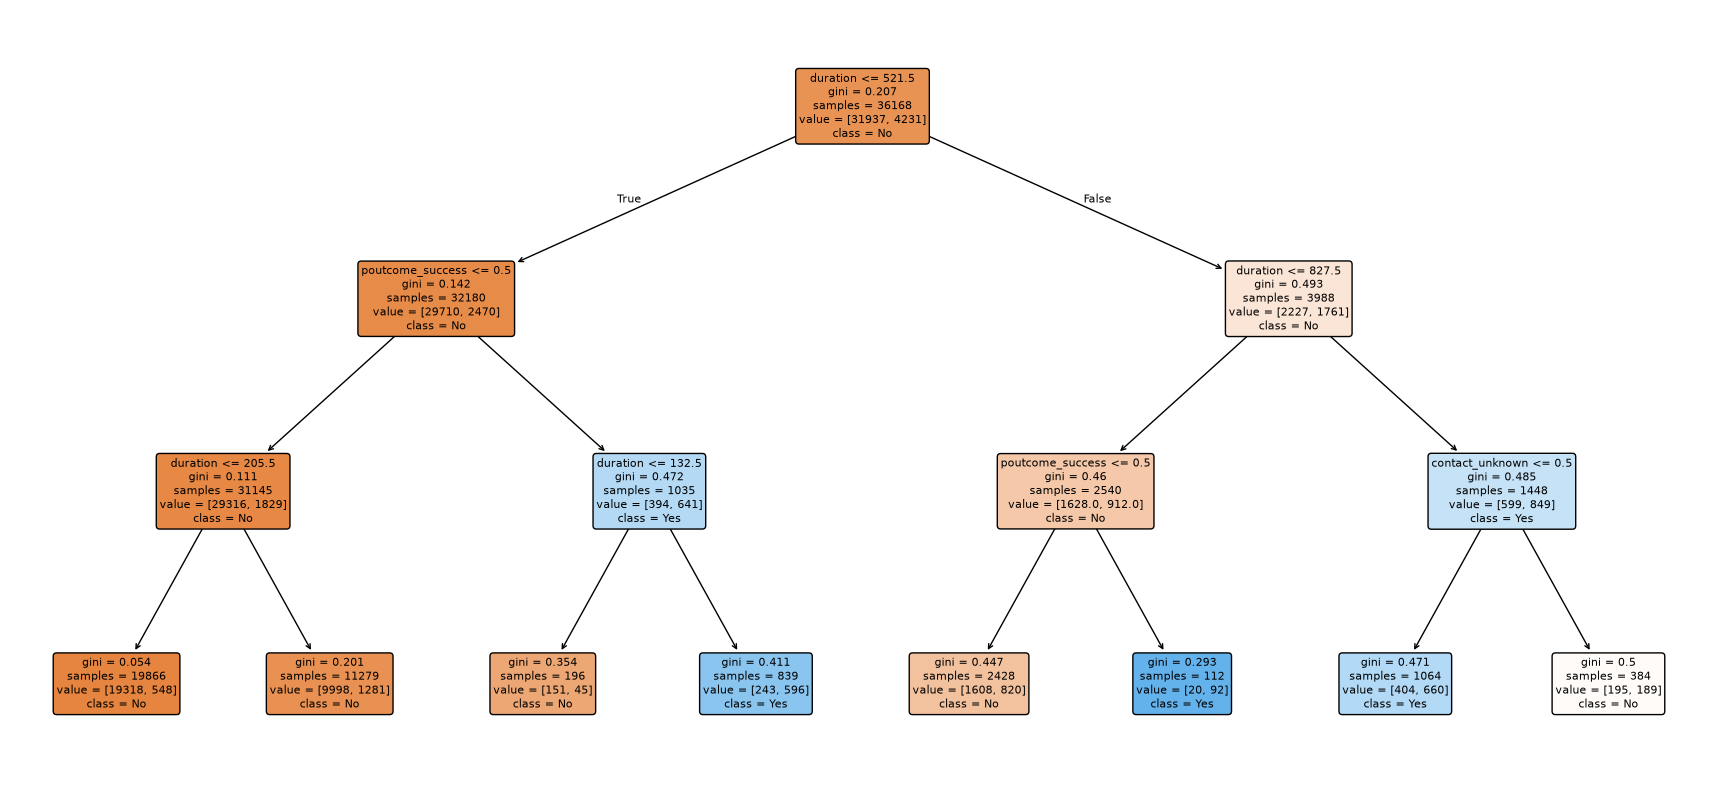

In [13]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_3,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()


### Read the tree

Look at the root node.

The tree is essentially asking:

> **"Is feature X less than or equal to some threshold?"**

Each answer sends the observation down a different branch.

Eventually the observation reaches a **leaf**, where the tree makes its prediction.

### Question 3

Find the root split.

1. What feature is being used?
2. What is the threshold?
3. What happens if the condition is true?
4. What happens if it is false?

Explain the path a new customer would take through the tree.

### Answers: 

* 
* 
*
*

## Part 9 — Why Does the Tree Choose That Split?

The tree needs a way to decide which split is useful.

One common measure is **Gini impurity**.

$$
Gini = 1 - \sum_{k=1}^{K} p_k^2
$$

For binary classification:

$$
Gini = 1 - p_0^2 - p_1^2
$$

A node containing only one class has Gini impurity of 0.

A node containing a mixture of classes has higher impurity.

The tree looks for splits that reduce impurity.

In [14]:
def gini(p):
    return 1 - sum(x**2 for x in p)


print("All customers are 'No':", gini([1.0, 0.0]))
print("50% No / 50% Yes:", gini([0.5, 0.5]))
print("90% No / 10% Yes:", gini([0.9, 0.1]))



All customers are 'No': 0.0
50% No / 50% Yes: 0.5
90% No / 10% Yes: 0.17999999999999994


### Question 4

A node contains 30 observations:

10 Class A

15 Class B

5 Class C

Calculate its Gini impurity.


### Answer: 

* 


## Part 10 — Gini Impurity in an Actual Tree Node

Let's inspect the impurity of the root node.

In [ ]:
tree_3.tree_.impurity[0]


The value above is the impurity at the root.

Now inspect the child nodes.

In [ ]:
for i in range(min(7, tree_3.tree_.node_count)):
    print(
        "Node", i,
        "| impurity =", round(tree_3.tree_.impurity[i], 4),
        "| samples =", tree_3.tree_.n_node_samples[i],
        "| value =", tree_3.tree_.value[i].flatten()
    )


### Think about it

A good split should create child nodes that are **more pure** than the parent node.

This is the central idea behind tree construction:

**Find a question that makes the resulting groups more homogeneous.**

## Part 11 — Entropy Instead of Gini

Another common impurity measure is entropy.

$$
H(S) = -\sum p_i \log_2(p_i)
$$

Information gain measures how much uncertainty is reduced by a split.

$$
IG = H(parent) - \sum_j \frac{N_j}{N}H(child_j)
    $$

You do not need to calculate every possible split by hand. The important idea is:

> **The algorithm searches for splits that produce purer child nodes.**

In [ ]:
tree_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)
tree_entropy.fit(X_train, y_train)
entropy_pred = tree_entropy.predict(X_test)
print("Entropy tree test accuracy:", accuracy_score(y_test, entropy_pred))


### Question 5

Compare the Gini and entropy trees.

1. Did they produce exactly the same performance?
2. Did they necessarily choose exactly the same splits?
3. What does this tell you about the role of the splitting criterion?


### Answers: 

* 
* 
*

## Part 12 — Let's Remove the Depth Limit

Now we will let the tree grow much more freely.

### Before running the code

Predict what will happen to:

- Training accuracy
- Test accuracy
- Number of leaves
- Tree depth

Write your prediction first.

In [ ]:
deep_tree = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
deep_tree.fit(X_train, y_train)
deep_train_pred = deep_tree.predict(X_train)
deep_test_pred = deep_tree.predict(X_test)
print("Training accuracy:", accuracy_score(y_train, deep_train_pred))
print("Test accuracy:    ", accuracy_score(y_test, deep_test_pred))
print("Tree depth:       ", deep_tree.get_depth())
print("Number of leaves: ", deep_tree.get_n_leaves())


## Part 13 — Discover Overfitting

Manually experiment and record the train and test accuracy using the following depth

| Model | Training accuracy | Test accuracy | Depth |
|---|---:|---:|---:|
| Depth 1 | | | 1 |
| Depth 2 | | | 2 |
| Depth 3 | | | 3 |
| Depth 5 | | | 5 |
| Depth 6 | | | 6 |
| Depth 7 | | | 7 |
| Depth 10 | | | 10 |
| Depth 12 | | | 12 |
| Deep tree | | | ? |

### Question 6

- If the deep tree has substantially higher training accuracy but worse test accuracy, what is happening?

Explain this in your own words.

- At what point does increasing complexity stop helping

### Answers: 

* 
* 

## Part 14 — The Tree Complexity Experiment

Now we will systematically change `max_depth`.

Your task is to discover what happens as the tree becomes more complex.

In [ ]:
depths = range(1, 16)
train_scores = []
test_scores = []
leaves = []
for depth in depths:
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))
    leaves.append(model.get_n_leaves())


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, marker='o', label='Training accuracy')
plt.plot(depths, test_scores, marker='o', label='Test accuracy')
plt.xlabel('Maximum tree depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Complexity vs Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Question 7 — Analyze the graph

Look carefully at the two curves.

1. What happens to training accuracy as depth increases?
2. What happens to test accuracy?
3. Is deeper always better?
4. At what point does increasing complexity appear to stop helping?
5. What does the gap between training and test accuracy tell you?

### Answers: 

* 
* 
*
*
*

## Part 15 — Control Overfitting with `min_samples_leaf`

`min_samples_leaf` specifies the minimum number of training examples that must remain in a leaf.

Increasing this value prevents the tree from creating very small leaves.

In [ ]:
leaf_values = [1, 5, 10, 20, 50, 100]
train_leaf_scores = []
test_leaf_scores = []
for leaf_size in leaf_values:
    model = DecisionTreeClassifier(
        random_state=42,
        min_samples_leaf=leaf_size
    )
    model.fit(X_train, y_train)
    train_leaf_scores.append(model.score(X_train, y_train))
    test_leaf_scores.append(model.score(X_test, y_test))


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(leaf_values, train_leaf_scores, marker='o', label='Training accuracy')
plt.plot(leaf_values, test_leaf_scores, marker='o', label='Test accuracy')
plt.xlabel('Minimum samples per leaf')
plt.ylabel('Accuracy')
plt.title('Effect of min_samples_leaf')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Question 8

What happens when we require larger leaves?

Explain why increasing `min_samples_leaf` can reduce overfitting.

### Answers: 

* 
* 

## Part 16 — Inspect the Most Important Features

Decision trees provide a measure called **feature importance**.

It reflects how much each feature contributes to reducing impurity across the tree.

Let's inspect the most important features.

In [ ]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
importance.head(15)


In [ ]:
importance.head(15).sort_values().plot(
    kind='barh',
    figsize=(10, 7)
)
plt.xlabel('Feature importance')
plt.title('Most Important Features')
plt.show()


### Question 9 — Interpretability

Look at the most important features.

1. Which features did you expect to be important?
2. Which surprised you?
3. Does feature importance tell us that a feature **causes** the outcome?
4. What additional analysis would you want before making a business decision based on this model?

### Answers: 

*
* 
*
* 

## Part 17 — Make Predictions for Individual Customers

One appealing property of decision trees is that we can explain a prediction as a sequence of decisions.

Let's select several test customers.

In [ ]:
sample = X_test.iloc[:5]
predictions = model.predict(sample)
results = sample.copy()
results['Predicted subscription'] = predictions
results


### Challenge

Pick one customer above.

Try to trace the customer through the decision tree manually.

Write an explanation such as:

> The customer first goes through condition X. Because the condition is true, the customer moves to the left branch. The next condition is Y...

This is one of the key differences between decision trees and many other machine-learning models: **the prediction can often be expressed as a sequence of human-readable rules.**

## Part 18 — Evaluate More Than Accuracy

Accuracy alone may not tell the whole story, particularly when the classes are imbalanced.

In [ ]:
final_pred = model.predict(X_test)
print(classification_report(
    y_test,
    final_pred,
    target_names=['No subscription', 'Subscription']
))


In [ ]:
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1], ['Predicted No', 'Predicted Yes'])
plt.yticks([0, 1], ['Actual No', 'Actual Yes'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()


### Question 10

Imagine you are the bank manager.

Would you care equally about:

- Predicting a customer will subscribe when they actually will not?
- Predicting a customer will not subscribe when they actually will?

Why might the **cost of different errors** matter when evaluating a classifier?

### Answers: 

*
* 

# Final Challenge — Build Your Own Tree

You are now the model designer.

Create a decision tree that you think provides a good balance between:

- predictive performance
- simplicity
- interpretability
- generalization

You may change:

- `max_depth`
- `min_samples_leaf`
- `criterion`

Do **not** simply maximize training accuracy.

In [ ]:
# YOUR MODEL

my_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=____,
    min_samples_leaf=____,
    random_state=42
)

my_tree.fit(X_train, y_train)
my_train_accuracy = my_tree.score(X_train, y_train)
my_test_accuracy = my_tree.score(X_test, y_test)
print("Training accuracy:", my_train_accuracy)
print("Test accuracy:", my_test_accuracy)
print("Depth:", my_tree.get_depth())
print("Leaves:", my_tree.get_n_leaves())


# Reflection

Reflect and Provide Answers to these questions

### 1. What does a decision tree actually learn?

Explain it without saying simply "it learns patterns."

### 2. What is impurity?

Explain it using the idea of mixed versus pure groups.

### 3. Why does the tree need Gini impurity or entropy?

What problem does the criterion solve?

### 4. Why can a very deep tree be dangerous?

Explain using training and test data.

### 5. Name two ways to control tree complexity.

### 6. Explain this statement:

> **A model with 100% training accuracy is not necessarily a good model.**

### 7. In one sentence, explain how a decision tree makes a prediction for a new observation.